# RDKit ligand

## Setup

In [ ]:
#| default_exp core.ligand

In [ ]:
#| export
import pandas as pd, numpy as np
from rdkit import Chem,RDLogger,DataStructs
from rdkit.Chem import Draw, rdDepictor, Descriptors,Descriptors3D, AllChem
from skfp.fingerprints import AtomPairFingerprint, ECFPFingerprint, MACCSFingerprint
import hashlib,numba
from kdock.core.data import *

from tqdm.contrib.concurrent import process_map
from tqdm import tqdm
RDLogger.DisableLog('rdApp.warning')

In [ ]:
#| hide
pd.set_option('display.max_rows', 5)
pd.set_option('display.max_columns', 100) # show all columns

In [ ]:
#| export
def plot_drug(drug_dict, flip_list=None, save_path=None):
    flip_list = flip_list or []
    mols = []

    for name, smi in drug_dict.items():
        mol = Chem.MolFromSmiles(smi)
        rdDepictor.Compute2DCoords(mol)

        # Flip horizontally if requested
        if name in flip_list:
            conf = mol.GetConformer()
            for i in range(conf.GetNumAtoms()):
                x, y, z = conf.GetAtomPosition(i)
                conf.SetAtomPosition(i, (-x, y, z))

        mol.SetProp("_Name", name)
        mols.append(mol)

    # Draw to SVG
    svg_obj = Draw.MolsToGridImage(
        mols,
        molsPerRow=3,
        subImgSize=(300, 250),
        legends=[m.GetProp("_Name") for m in mols],
        useSVG=True
    )

    svg_str = getattr(svg_obj, "data", getattr(svg_obj, "GetDrawingText", lambda: svg_obj)())

    if save_path:
        with open(save_path, "w", encoding="utf-8") as f:
            f.write(svg_str)
        print(f"✅ Saved structure grid to: {save_path}")
    else:
        # from IPython.display import SVG, display
        # display(SVG(svg_str))
        return svg_obj

In [ ]:
drug_smiles = {
    "Capmatinib": "CNC(=O)C1=C(C=C(C=C1)C2=NN3C(=CN=C3N=C2)CC4=CC5=C(C=C4)N=CC=C5)F",
    "Tepotinib": "CN1CCC(CC1)COC2=CN=C(N=C2)C3=CC=CC(=C3)CN4C(=O)C=CC(=N4)C5=CC=CC(=C5)C#N",}

flip_list = ['Tepotinib'] # indicate keys to flip horizontally
plot_drug(drug_smiles,
          flip_list=flip_list,
        #   save_path='drug_structures.svg'
          )

## Conformer

In [ ]:
#| export
def rdkit_conformer(SMILES, # SMILES string
                    output=None, # file ".sdf" to be saved
                    method='ETKDG', # Optimization method, can be 'UFF', 'MMFF' or 'ETKDGv3'
                    visualize=True, #whether or not to visualize the compound
                    seed = 3,# randomness of the 3D conformation
                    ):

    "Gemerate 3D conformers from SMILES"
    
    np.random.seed(seed) 
    mol = Chem.MolFromSmiles(SMILES)
    
    # Generate a 3D conformation of the molecule
    AllChem.EmbedMolecule(mol)
    

    # Optimize the 3D conformation using the specified force field method
    if method == 'UFF':
        AllChem.UFFOptimizeMolecule(mol)
    elif method == 'MMFF':
        AllChem.MMFFOptimizeMolecule(mol)
    elif method == 'ETKDG':
        AllChem.EmbedMultipleConfs(mol, numConfs=1, useExpTorsionAnglePrefs=True, 
                                   useBasicKnowledge=True, enforceChirality=True,randomSeed=seed)
        AllChem.ETKDGv3()
        AllChem.UFFOptimizeMolecule(mol)

    else:
        raise ValueError('Invalid method specified')
        

    # Remove hydrogens from the molecule
    # mol = Chem.RemoveHs(mol)

    if output is not None:
        Path(output).parent.mkdir(parents=True,exist_ok=True)
    
        w = Chem.SDWriter(output)
        w.write(mol)
        w.close()
    return mol

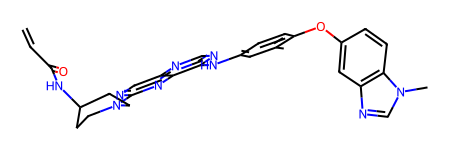

In [ ]:
rdkit_conformer('CC1=C(C=CC(=C1)NC2=NC=NC3=CN=C(N=C32)N4CCC(CC4)NC(=O)C=C)OC5=CC6=C(C=C5)N(C=N6)C')

In [ ]:
#| export
def tanimoto(df, # df with SMILES and ID columns
             smiles_col='SMILES', # colname of SMILES
             id_col='ID', # colname of compound ID
             target_col=None, # colname of compound values (e.g., IC50)
             radius=2, # radius of the Morgan fingerprint.
             ):
    "Calculates the Tanimoto similarity scores between all pairs of molecules in a pandas DataFrame."
    
    df = df.copy()
    # Convert SMILES to molecule objects
    df['Molecule'] = df[smiles_col].apply(lambda x: Chem.MolFromSmiles(x))

    # Calculate fingerprints
    df['Fingerprint'] = df['Molecule'].apply(lambda x: AllChem.GetMorganFingerprintAsBitVect(x, radius))

    # Calculate similarity scores
    similarity_scores = []
    for i in range(len(df)):
        for j in range(i+1, len(df)):
            sim_score = DataStructs.TanimotoSimilarity(df['Fingerprint'][i], df['Fingerprint'][j])
            if target_col is not None:
                similarity_scores.append((df[id_col][i], df[id_col][j], df[smiles_col][i], df[smiles_col][j], sim_score, df[target_col][i], df[target_col][j]))
            else:
                similarity_scores.append((df[id_col][i], df[id_col][j], df[smiles_col][i], df[smiles_col][j], sim_score))

    # Create a new DataFrame with the similarity scores
    if target_col is not None:
        result_df = pd.DataFrame(similarity_scores, columns=['ID1', 'ID2', 'SMILES1', 'SMILES2', 'SimilarityScore', 'Target1', 'Target2'])
    else:
        result_df = pd.DataFrame(similarity_scores, columns=['ID1', 'ID2', 'SMILES1', 'SMILES2', 'SimilarityScore'])

    # Sort by similarity score in descending order
    result_df.sort_values('SimilarityScore', ascending=False, inplace=True)
    result_df = result_df.reset_index(drop=True)

    return result_df

In [ ]:
df = Kras.get_mirati_g12d_raw()[['ID','SMILES','IC50']]
df = df.dropna(subset= 'IC50').reset_index(drop=True)
df

,ID,SMILES,IC50
0,US_1,CN1CCC[C@H]1COc1nc(N2CC3CCC(C2)N3)c2cnc(cc2n1)...,124.7
1,US_2,CN1CCC[C@H]1COc1nc(N2CC3CCC(C2)N3)c2cnc(c(F)c2...,2.7
...,...,...,...
703,paper_37,FC1=C(C2=C(C(Cl)=CC=C3)C3=CC(O)=C2)N=CC4=C1N=C...,2.0
704,paper_38,FC1=C(C2=C(C(C#C)=CC=C3)C3=CC(O)=C2)N=CC4=C1N=...,2.0


In [ ]:
result = tanimoto(df.head(), target_col = 'IC50')
result

,ID1,ID2,SMILES1,SMILES2,SimilarityScore,Target1,Target2
0,US_3,US_4,Cn1ccnc1CCOc1nc(N2CC3CCC(C2)N3)c2cnc(c(F)c2n1)...,Oc1cc(-c2ncc3c(nc(OCCc4ccccn4)nc3c2F)N2CC3CCC(...,0.779221,9.5,496.2
1,US_1,US_2,CN1CCC[C@H]1COc1nc(N2CC3CCC(C2)N3)c2cnc(cc2n1)...,CN1CCC[C@H]1COc1nc(N2CC3CCC(C2)N3)c2cnc(c(F)c2...,0.743590,124.7,2.7
...,...,...,...,...,...,...,...
8,US_1,US_3,CN1CCC[C@H]1COc1nc(N2CC3CCC(C2)N3)c2cnc(cc2n1)...,Cn1ccnc1CCOc1nc(N2CC3CCC(C2)N3)c2cnc(c(F)c2n1)...,0.505495,124.7,9.5
9,US_1,US_4,CN1CCC[C@H]1COc1nc(N2CC3CCC(C2)N3)c2cnc(cc2n1)...,Oc1cc(-c2ncc3c(nc(OCCc4ccccn4)nc3c2F)N2CC3CCC(...,0.488889,124.7,496.2


## Rdkit feature

In [ ]:
#| export
def get_rdkit(SMILES:str):
    """
    Extract chemical features from SMILES
    Reference: https://greglandrum.github.io/rdkit-blog/posts/2022-12-23-descriptor-tutorial.html
    """
    mol = Chem.MolFromSmiles(SMILES)
    return Descriptors.CalcMolDescriptors(mol)

In [ ]:
#| export
def get_rdkit_3d(SMILES:str):
    "Extract 3d features from SMILES"
    mol = Chem.MolFromSmiles(SMILES)
    mol = Chem.AddHs(mol)
    AllChem.EmbedMolecule(mol, AllChem.ETKDG())
    AllChem.UFFOptimizeMolecule(mol)
    return Descriptors3D.CalcMolDescriptors3D(mol)

In [ ]:
#| export
def get_rdkit_all(SMILES:str):
    "Extract chemical features and 3d features from SMILES"
    feat = get_rdkit(SMILES)
    feat_3d = get_rdkit_3d(SMILES)
    return feat|feat_3d

In [ ]:
#| export
def remove_hi_corr(df: pd.DataFrame, 
                   thr=0.99 # threshold
                   ):
    "Remove highly correlated features in a dataframe given a pearson threshold"
    corr_matrix = df.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > thr)]
    return df.drop(to_drop, axis=1), to_drop

In [ ]:
#| export
def preprocess(df: pd.DataFrame, thr=0.99):
    "Remove features with no variance, and highly correlated features based on threshold."
    col_ori = df.columns

    # Remove columns with std == 0
    std_zero_cols = df.columns[df.std() == 0].tolist()
    
    if std_zero_cols:
        n=len(std_zero_cols)
        print(f"\n {n} Columns with zero std: {std_zero_cols}")
    df = df.loc[:, df.std() != 0].copy()

    # Remove highly correlated columns
    df, high_corr_cols = remove_hi_corr(df, thr)
    if high_corr_cols:
        n=len(high_corr_cols)
        print(f"\n {n} Columns removed due to high similarity (pearson>{thr}): {high_corr_cols}")

    dropping_col = set(col_ori) - set(df.columns)
    n = len(dropping_col)
    print(f"\n Total removed columns: {n}")
    
    return df

In [ ]:
#| export
def get_rdkit_df(df: pd.DataFrame,
                 include_3d=False,
                 col='SMILES',
                 postprocess=False,
                 chunksize=128, # for parallel process_map 
                 ):
    "Extract rdkit features (optionally in parallel with 3D) from SMILES in a df"
    func = get_rdkit_all if include_3d else get_rdkit
    smiles_list = df[col].tolist()

    features = process_map(func, smiles_list,chunksize=chunksize)

    out = pd.DataFrame(features)

    if postprocess:
        out = StandardScaler().fit_transform(out)
        out = preprocess(out) # remove redundant

    return out

In [ ]:
df=Collins.get_antibiotics_2k().head(300)
df.head()

,name,SMILES,inhibition,activity
0,CEFPIRAMIDE,Cc1cc(O)c(C(=O)NC(C(=O)NC2C(=O)N3C(C(=O)O)=C(C...,0.041572,1
1,GEMIFLOXACIN MESYLATE,CON=C1CN(c2nc3c(cc2F)c(=O)c(C(=O)O)cn3C2CC2)CC...,0.041876,1
2,POLYMYXIN B SULFATE,CCC(C)CCCCC(=O)NC(CCN)C(=O)NC(C(=O)NC(CCN)C(=O...,0.041916,1
3,PRAXADINE HYDROCHLORIDE,Cl.N=C(N)n1cccn1,0.041964,1
4,CHLORHEXIDINE DIHYDROCHLORIDE,Cl.Cl.N=C(NCCCCCCNC(=N)NC(=N)Nc1ccc(Cl)cc1)NC(...,0.042295,1


In [ ]:
# %%time
# feat_raw=get_rdkit_df(df)
# feat_raw

  0%|          | 0/300 [00:00<?, ?it/s]

CPU times: user 46.6 ms, sys: 65.7 ms, total: 112 ms
Wall time: 2.63 s


,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,AvgIpc,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3n,Chi3v,Chi4n,Chi4v,HallKierAlpha,Ipc,Kappa1,Kappa2,Kappa3,LabuteASA,PEOE_VSA1,PEOE_VSA10,PEOE_VSA11,...,fr_benzodiazepine,fr_bicyclic,fr_diazo,fr_dihydropyridine,fr_epoxide,fr_ester,fr_ether,fr_furan,fr_guanido,fr_halogen,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_imide,fr_isocyan,fr_isothiocyan,fr_ketone,fr_ketone_Topliss,fr_lactam,fr_lactone,fr_methoxy,fr_morpholine,fr_nitrile,fr_nitro,fr_nitro_arom,fr_nitro_arom_nonortho,fr_nitroso,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_phos_acid,fr_phos_ester,fr_piperdine,fr_piperzine,fr_priamide,fr_prisulfonamd,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,13.503995,13.503995,0.064423,-1.323430,0.162954,18.619048,612.650,588.458,612.120937,218,0,0.352159,-0.507967,0.507967,0.352159,1.214286,1.952381,2.595238,32.167943,10.004034,2.541608,-2.492828,2.413335,-2.707792,8.005500,-0.150504,3.369454,1.339505e+00,1610.181663,30.128663,22.084778,23.717771,20.044622,12.357347,14.391701,9.367961,11.415452,6.531851,8.968356,4.422333,6.757255,-4.64,2.012862e+09,28.873109,11.690583,5.597490,245.926226,25.953159,34.653617,0.000000,...,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,1,0,2,0,0,0,1,0,0,0,0,0
1,14.874521,14.874521,0.033885,-3.666667,0.398220,19.484848,485.494,461.302,485.138047,180,0,0.340725,-0.477497,0.477497,0.340725,1.424242,2.060606,2.575758,32.239615,10.092419,2.328029,-2.190189,2.370431,-2.256089,7.845502,0.069447,3.471950,5.549999e-07,1265.508949,24.499271,17.933021,18.749518,15.439091,9.902198,11.750510,7.791830,9.257870,5.167537,5.167537,3.595955,3.595955,-3.10,1.783676e+07,24.540619,9.407810,5.638555,187.744947,25.144793,18.320426,11.635084,...,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,11.161773,11.161773,0.278802,-0.471329,0.463380,10.423077,354.358,336.214,354.110338,134,0,0.307526,-0.426733,0.426733,0.307526,0.615385,1.038462,1.500000,16.546477,10.114910,2.058887,-2.069790,2.248839,-2.041320,5.751292,-0.132566,2.519358,2.225734e+00,814.855170,19.104084,14.645642,14.645642,12.312571,7.801219,7.801219,5.421051,5.421051,3.035442,3.035442,2.145140,2.145140,-3.41,4.201281e+05,18.921939,8.617804,6.238343,150.543633,14.210589,17.248535,0.000000,...,0,0,0,0,0,3,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
299,6.134942,6.134942,0.000000,0.000000,0.709648,16.421053,412.597,391.429,409.976001,108,0,0.050449,-0.397550,0.397550,0.050449,1.210526,1.842105,2.473684,79.919764,9.939734,2.186581,-2.311907,2.301302,-2.326367,9.108394,0.184585,2.360656,1.804999e-06,420.152146,13.120956,11.163433,15.151922,8.575387,6.513030,8.099027,5.167360,6.937372,3.797772,4.911697,2.688476,4.002186,0.23,1.225652e+04,17.282002,7.866121,4.622779,138.333022,5.733667,0.000000,0.000000,...,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
# feat = get_rdkit_df(df,postprocess=True)
# feat

## Morgan fingerprints (ECFP)

Reference:

- [kaggle notebook, scikit-fingerprints](https://www.kaggle.com/code/michaszafarczyk/molecular-fingerprints-using-scikit-fingerprints)
- [scikit-fingerprints github](https://github.com/scikit-fingerprints/scikit-fingerprints)
- [kaggle notebook, fingerprint tips and tricks](https://www.kaggle.com/code/towardsentropy/fingerprint-tips-and-tricks)

In [ ]:
#| export
def get_fp(SMILES, 
           name='ecfp',
           ELEMENTS_PER_WORKER = 1_000_000):
    "Super fast method to get molecule fingerprints using scikit-fingerprints"
    if name == 'ecfp':
        fp_transformer = ECFPFingerprint(fp_size=2048, radius=3, n_jobs=-1)
    elif name == 'ap':
        fp_transformer = AtomPairFingerprint(fp_size=2048, n_jobs=-1)
    elif name == 'maccs':
        fp_transformer = MACCSFingerprint(n_jobs=-1)
    else:
        raise Exception('Wrong fingerprint name!')
    
    middle_parts = []
    k_splits = len(SMILES) // ELEMENTS_PER_WORKER
        
    for i in tqdm(range(k_splits)):
        middle_parts.append(fp_transformer.transform(SMILES[i * ELEMENTS_PER_WORKER: (i + 1) * ELEMENTS_PER_WORKER]))
        
    if len(SMILES) % ELEMENTS_PER_WORKER > 0:   
        middle_parts.append(fp_transformer.transform(SMILES[k_splits * ELEMENTS_PER_WORKER:]))
    
    return np.concatenate(middle_parts)

In [ ]:
# %%time
# fp = get_fp(df.SMILES, name='ecfp')
# fp

0it [00:00, ?it/s]


CPU times: user 21.2 ms, sys: 78 ms, total: 99.2 ms
Wall time: 2.07 s


array([[0, 1, 1, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0]], dtype=uint8)

## Use np.packbits to save space
> Save space when dealing with super big dataset

Packbits will transform binary to decimals, if it is [1, 0, 1, 1, 0, 0, 0, 0, 1, 1], then it will take 8 bits in the sequence, [10110000] and [11000000], for the latter, if not enough for 8 bits length, it will add 0. 

To transform binary to decimals, take [10110000] for example, calculate through 1*2^7 + 0*2^6 + 1*2^5 + 1*2^4 + 0*2^3 + 0*2^2 + 0*2^1 + 0*2^0=176

In [ ]:
#| export
def compress_fp(array):
    "Compress binary finterprints using np.packbits"
    return np.packbits(array,axis=1)

In [ ]:
# compress_fp(fp)

array([[100,   0,   0, ...,  16,   0,   0],
       [  0, 128,   0, ...,   0,   0,   0],
       [ 64,   0,   0, ...,   0,  16,   0],
       ...,
       [  0, 128,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,  64,   0],
       [ 32,   0,   0, ...,   0,   0,   0]], dtype=uint8)

## Tanimoto

Reference: https://www.kaggle.com/code/towardsentropy/fingerprint-tips-and-tricks/notebook

Slow version:

Method 1

In [ ]:
from scipy.spatial import distance

In [ ]:
# %%time
# tanimotos_scipy = 1-distance.cdist(fp, fp, metric='jaccard')
# # 30.4s

A little faster with parallel

In [ ]:
from sklearn.metrics import pairwise_distances

In [ ]:
# %%time
# tanimotos_sklearn = 1 - pairwise_distances(fp, metric='jaccard', n_jobs=-1)
# # 13.1s

Method 2

In [ ]:
from rdkit.Chem import DataStructs

In [ ]:
# %%time
# tanimotos_rdkit = np.array([DataStructs.BulkTanimotoSimilarity(i, fp) for i in fp])

Method 3

In [ ]:
def tanimoto_bitwise(fps_np):
    intersection = (fps_np[:,None] & fps_np[None]).sum(-1)
    union = (fps_np[:,None] | fps_np[None]).sum(-1)
    return intersection / union

In [ ]:
# tanimoto_bitwise(fp)

### Numba tanimoto

In [ ]:
#| export
@numba.njit(parallel=True)
def tanimoto_numba(fps):
    "Get a NxN matrix of tanimoto similarity among N compounds."
    n = fps.shape[0]
    result = np.zeros((n, n), dtype=np.float32)
    
    for i in numba.prange(n):
        for j in range(i, n):  # only upper triangle
            inter = np.bitwise_and(fps[i], fps[j]).sum()
            union = np.bitwise_or(fps[i], fps[j]).sum()
            sim = inter / union if union > 0 else 0.0
            result[i, j] = sim
            result[j, i] = sim  # fill symmetric position
    return result

In [ ]:
# %%time
# tanimoto_numba(fp)

CPU times: user 2.02 s, sys: 319 ms, total: 2.34 s
Wall time: 2.4 s


array([[1.        , 0.11695907, 0.12676056, ..., 0.04918033, 0.06617647,
        0.06206897],
       [0.11695907, 1.        , 0.13020833, ..., 0.09375   , 0.0990991 ,
        0.09166667],
       [0.12676056, 0.13020833, 1.        , ..., 0.06206897, 0.05555556,
        0.07142857],
       ...,
       [0.04918033, 0.09375   , 0.06206897, ..., 1.        , 0.03508772,
        0.0625    ],
       [0.06617647, 0.0990991 , 0.05555556, ..., 0.03508772, 1.        ,
        0.0625    ],
       [0.06206897, 0.09166667, 0.07142857, ..., 0.0625    , 0.0625    ,
        1.        ]], dtype=float32)

## Group same compounds
> Utilize hash sha256 to encode morgan fp and find same molecule

In [ ]:
#| export
def hash_fp(fp_row):
    "Hash a binary fingerprint row using SHA256"
    return hashlib.sha256(fp_row.tobytes()).hexdigest()

In [ ]:
# hash_fp(fp[0])

'8deb65ba1323d46ca59ebf1206a497761ed2b83a518aa7227a965d5426e25aea'

In [ ]:
#| export
def get_same_mol_group(df, smi_col='SMILES'):
    "Assign a group number to the same compounds by utilizing hash sha256 to encode morgan fp and find same molecule."
    df = df.copy()
    smiles = df[smi_col].tolist()
    
    fps = get_fp(smiles)
    
    # Hash each fingerprint
    # hashes = [hash_fp(fp) for fp in fps] # non-parallel
    hashes = process_map(hash_fp, fps, chunksize=256) # if parallel
    
    # Assign a group number based on hash buckets
    hash_to_group = {}
    group_ids = []
    group_counter = 0
    for h in hashes:
        if h not in hash_to_group:
            hash_to_group[h] = group_counter
            group_counter += 1
        group_ids.append(hash_to_group[h])
    
    df['group'] = group_ids
    return df

In [ ]:
# %%time
# df2 = get_same_mol_group(df)
# df2.group.value_counts()

0it [00:00, ?it/s]


  0%|          | 0/300 [00:00<?, ?it/s]

CPU times: user 26.4 ms, sys: 124 ms, total: 151 ms
Wall time: 237 ms


group
0      1
206    1
      ..
96     1
299    1
Name: count, Length: 300, dtype: int64

## End

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()